# Hand classifier
This model identifies the number of extended fingers based on a clear image of a human hand.

In [1]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
from keras import layers

import numpy as np
import matplotlib.pyplot as plt

from keras import backend as K
print(K.backend())

C:\Users\Omistaja\anaconda3\envs\keras\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


tensorflow


In [2]:
from sklearn.model_selection import train_test_split
batch_size_n = 4
img_size = (224, 224)

train_dataset, validation_dataset = keras.utils.image_dataset_from_directory(
    'images/train',
    batch_size=batch_size_n, 
    image_size=img_size,
    crop_to_aspect_ratio=True,
    label_mode='categorical',
    validation_split=0.177, # ensures validation and test sets are equal size
    subset='both',
    shuffle=True,
    seed=123)

test_dataset = keras.utils.image_dataset_from_directory(
    'images/test',
    batch_size=batch_size_n, 
    image_size=img_size,
    crop_to_aspect_ratio=True,
    shuffle=False,
    label_mode='categorical')

Found 255 files belonging to 5 classes.
Using 210 files for training.
Using 45 files for validation.
Found 45 files belonging to 5 classes.


In [3]:
from keras import Sequential
from keras import layers
from keras.optimizers import Adam
num_classes = 5

model = Sequential([
    layers.Input(shape=(224, 224, 3)),
    
    # Processing / augmentation
    layers.Rescaling(1./255),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),

    # Convolution
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(128, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Output
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate = 0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

In [4]:
history = model.fit(train_dataset, batch_size=4, epochs=50, validation_data=validation_dataset)

Epoch 1/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.1714 - loss: 1.6949 - val_accuracy: 0.1556 - val_loss: 1.6114
Epoch 2/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.1762 - loss: 1.6137 - val_accuracy: 0.1333 - val_loss: 1.6139
Epoch 3/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.2048 - loss: 1.6072 - val_accuracy: 0.1333 - val_loss: 1.6225
Epoch 4/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.1857 - loss: 1.6157 - val_accuracy: 0.1778 - val_loss: 1.6097
Epoch 5/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.1857 - loss: 1.6108 - val_accuracy: 0.2222 - val_loss: 1.6107
Epoch 6/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.2095 - loss: 1.6089 - val_accuracy: 0.3333 - val_loss: 1.6115
Epoch 7/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.2333 - loss: 1.6143 - val_accuracy: 0.3778 - val_loss: 1.6068
Epoch 8/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.2381 - loss: 1.6085 - val_accuracy: 0.2222 - v

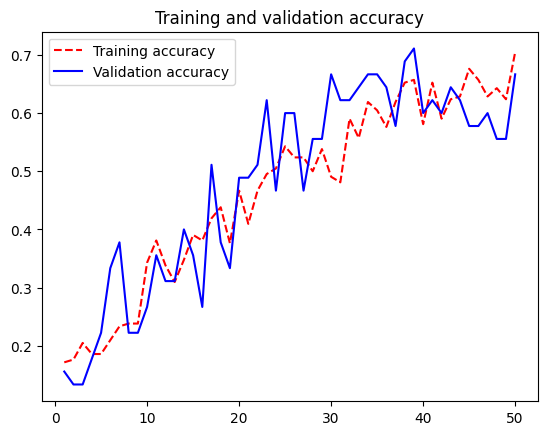

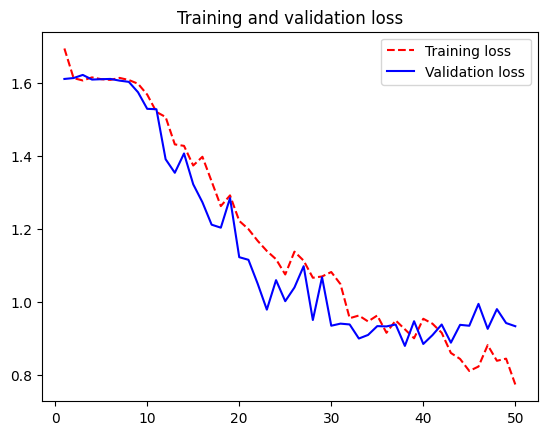

In [5]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, "r--", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [6]:
loss, acc = model.evaluate(test_dataset, verbose=0)
print(f"The model's test accuracy is {acc}")

The model's test accuracy is 0.6000000238418579


The convolutional model that was trained with these images from the beginning achieved an accuracy between 66-68%.
With 5 classes this means that the model has found some patterns and isn't just making wild guesses.  

Next, visualizing the model's predictions might make it easier to understand.

In [7]:
y_pred = model.predict(test_dataset)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(np.concatenate([y for x, y in test_dataset], axis=0), axis=1)

print(y_pred_classes)
print(y_true_classes)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
[0 0 0 0 0 1 0 0 2 1 0 0 1 1 1 1 2 2 3 2 3 3 2 2 2 2 2 2 2 2 3 3 2 4 3 2 2
 4 4 3 4 2 4 4 4]
[0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 3 4
 4 4 4 4 4 4 4 4]


In [8]:
images = []
labels = []
class_names = ['1 finger', '2 fingers', '3 fingers', '4 fingers', '5 fingers']

for image_batch, label_batch in test_dataset:
    images.append(image_batch.numpy())
    labels.append(label_batch.numpy())

images = np.concatenate(images)
labels = np.concatenate(labels)

In [9]:
def show_example_images_and_predictions(predicted_labels):
    plt.figure(figsize=(15, 8))
    
    for i in range(20):
        plt.subplot(4, 5, i + 1)
    
        plt.imshow(images[i].astype("uint8"))
    
        true_label = y_true_classes[i]
        pred_label = predicted_labels[i]
    
        color = "green" if true_label == pred_label else "red"
    
        plt.title(
            f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}",
            color=color
        )
    
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

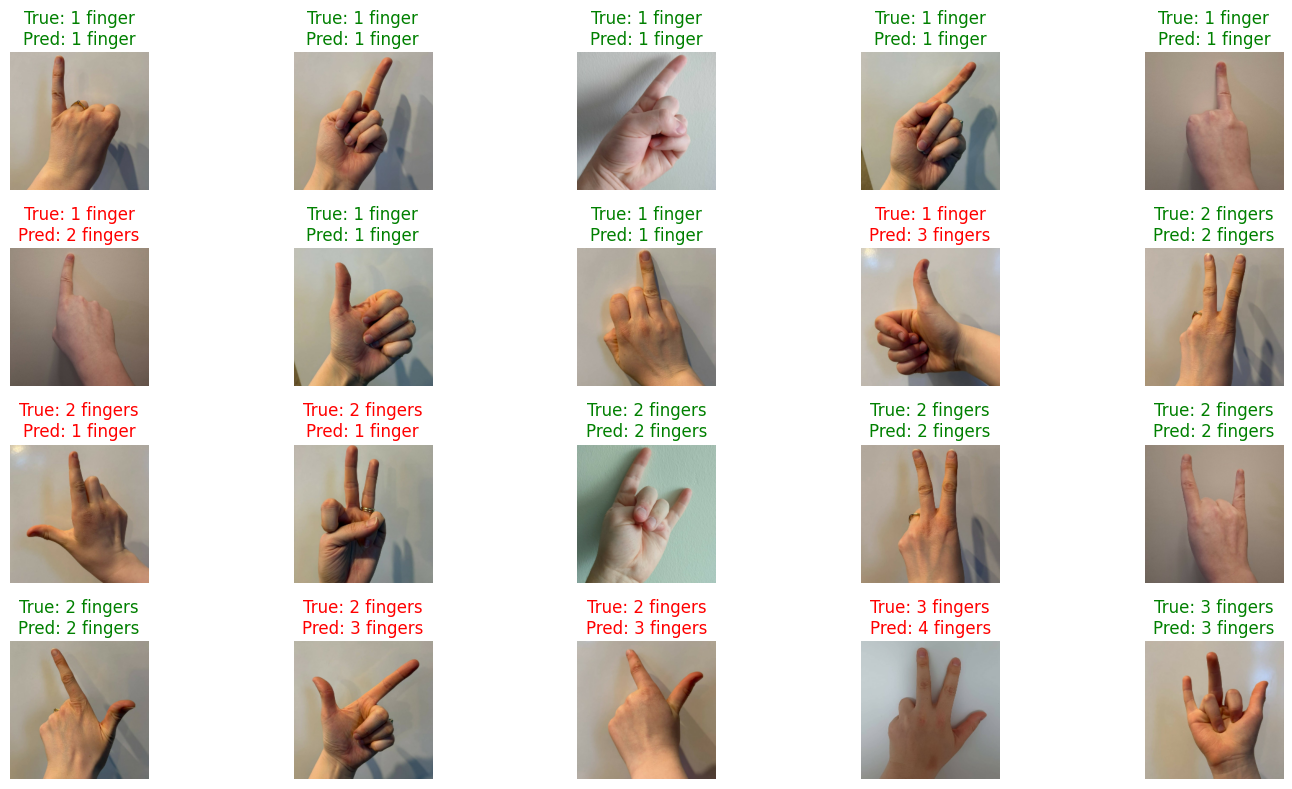

In [10]:
show_example_images_and_predictions(y_pred_classes)